# 03_sequence_generation

Goals:
- load processed FD001 train/test data
- load selected feature columns
- create sliding-window training sequences
- create one final sequence per test engine
- align test sequences with ground-truth RUL
- save numpy arrays for model training

In [13]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.sequence import create_train_sequences, create_test_sequences

In [14]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
df_train = pd.read_csv(PROCESSED_DIR / "train_fd001_processed.csv")
df_test = pd.read_csv(PROCESSED_DIR / "test_fd001_processed.csv")
df_rul_test = pd.read_csv(PROCESSED_DIR / "rul_fd001_test.csv")
feature_cols = pd.read_csv(PROCESSED_DIR / "fd001_feature_cols.csv", header=None)[0].tolist()

print("Train processed shape:", df_train.shape)
print("Test processed shape:", df_test.shape)
print("Test RUL shape:", df_rul_test.shape)
print("Number of features:", len(feature_cols))
print("Feature columns:", feature_cols)

Train processed shape: (20631, 27)
Test processed shape: (13096, 26)
Test RUL shape: (100, 1)
Number of features: 15
Feature columns: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## Sequence length
We use a sliding window of 30 cycles for the initial LSTM baseline (modified later in experiments).

In [16]:
SEQ_LENGTH = 30
print("Sequence length:", SEQ_LENGTH)

Sequence length: 30


In [17]:
X_train, y_train = create_train_sequences(df_train, feature_cols, SEQ_LENGTH)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17731, 30, 15)
y_train shape: (17731,)


In [18]:
X_test = create_test_sequences(df_test, feature_cols, SEQ_LENGTH)
y_test = df_rul_test["RUL"].values

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 30, 15)
y_test shape: (100,)


In [19]:
print("Single training sample shape:", X_train[0].shape)
print("Single test sample shape:", X_test[0].shape)
print("First training label:", y_train[0])
print("First test label:", y_test[0])

Single training sample shape: (30, 15)
Single test sample shape: (30, 15)
First training label: 100.0
First test label: 112


In [20]:
pd.DataFrame(X_train[0], columns=feature_cols).head()

,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


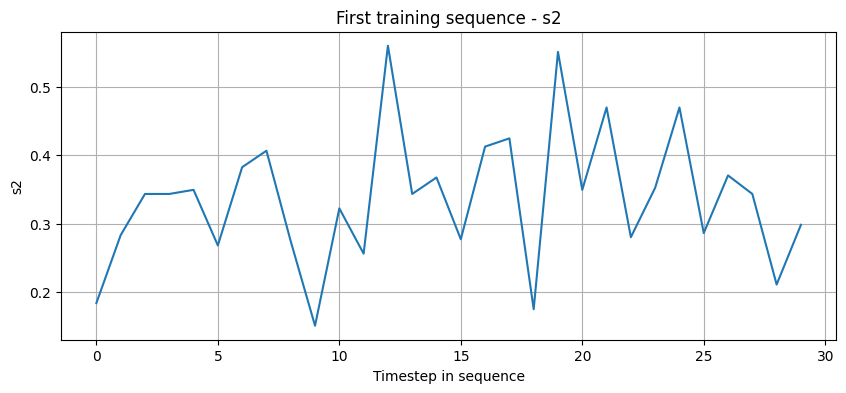

In [21]:
feature_name = feature_cols[0]

plt.figure(figsize=(10, 4))
plt.plot(X_train[0][:, feature_cols.index(feature_name)])
plt.xlabel("Timestep in sequence")
plt.ylabel(feature_name)
plt.title(f"First training sequence - {feature_name}")
plt.grid(True)
plt.show()

In [22]:
np.save(PROCESSED_DIR / "X_train.npy", X_train)
np.save(PROCESSED_DIR / "y_train.npy", y_train)
np.save(PROCESSED_DIR / "X_test.npy", X_test)
np.save(PROCESSED_DIR / "y_test.npy", y_test)

print("Saved sequence arrays to processed directory.")

Saved sequence arrays to processed directory.


In [23]:
print("Test engines:", df_test["unit"].nunique())
print("Test labels:", len(y_test))

Test engines: 100
Test labels: 100


In [24]:
test_lengths = df_test.groupby("unit").size()
print("Minimum test engine length:", test_lengths.min())
print("Maximum test engine length:", test_lengths.max())

Minimum test engine length: 31
Maximum test engine length: 303
